In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import math 
import matplotlib.patches as patches
import nibabel as nib 
import seaborn as sns

In [2]:
def nms(output, nms_th):
    if len(output) == 0:
        return output

    output = output[np.argsort(-output[:, 0])]
    bboxes = [output[0]]
    
    for i in np.arange(1, len(output)):
        bbox = output[i]
        flag = 1
        for j in range(len(bboxes)):
            if iou(bbox[1:5], bboxes[j][1:5]) >= nms_th:
                flag = -1
                break
        if flag == 1:
            bboxes.append(bbox)
    
    bboxes = np.asarray(bboxes, np.float32)
    return bboxes

def iou(box0, box1):
    
    r0 = box0[3] / 2
    s0 = box0[:3] - r0
    e0 = box0[:3] + r0

    r1 = box1[3] / 2
    s1 = box1[:3] - r1
    e1 = box1[:3] + r1

    overlap = []
    for i in range(len(s0)):
        overlap.append(max(0, min(e0[i], e1[i]) - max(s0[i], s1[i])))

    intersection = overlap[0] * overlap[1] * overlap[2]
    union = box0[3] * box0[3] * box0[3] + box1[3] * box1[3] * box1[3] - intersection
    return intersection / union

In [8]:
img = np.load("/home-local/krishar1/DeepLungScreening/mcl_adenocarcinoma_no_nodule_size/4774220022time20170101_clean.npy")
pbb = np.load("/home-local/krishar1/DeepLungScreening/bbox_root_mcl_adenocarcinoma/4774220022time20170101_pbb.npy")

In [10]:
pbb.shape

(34, 5)

In [23]:
pbb = pbb[pbb[:,0]>-1]
pbb = nms(pbb,0.05)
box = pbb[1].astype('int')[1:]

box, pbb.shape

(array([145, 181,  41,   8]), (2, 5))

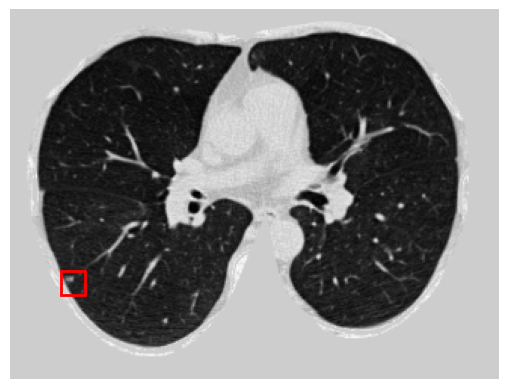

In [22]:
ax = plt.subplot(1,1,1)
plt.imshow(img[0,box[0]],'gray')
plt.axis('off')
rect = patches.Rectangle((box[2]-box[3],box[1]-box[3]),box[3]*2,box[3]*2,linewidth=2,edgecolor='red',facecolor='none')
ax.add_patch(rect)

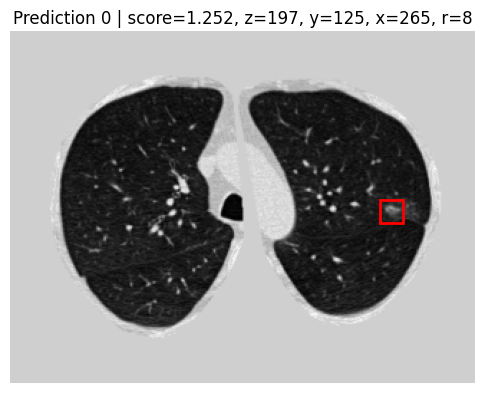

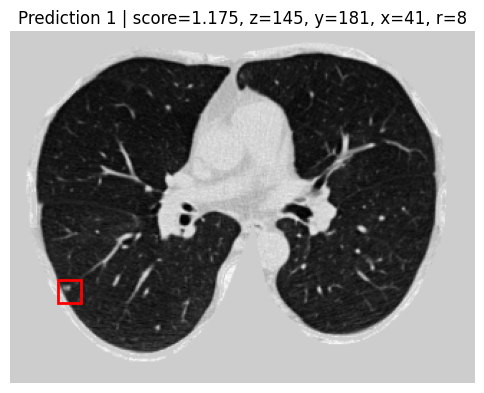

In [25]:
# for k in range(len(pbb)):
#     score, z, y, x, d = pbb[k]
#     z, y, x, d = int(z), int(y), int(x), int(d)

#     ax = plt.subplot(1, 1, 1)
#     plt.imshow(img[0, z], 'gray')
#     plt.axis('off')

#     rect = patches.Rectangle((box[2]-box[3],box[1]-box[3]),box[3]*2,box[3]*2,linewidth=2,edgecolor='red',facecolor='none')

#     ax.add_patch(rect)
#     plt.title(f"Prediction {k}, score={score:.3f}, z={z}, diameter={d}")
#     plt.show()
for i in range(len(pbb)):
    score = pbb[i, 0]
    box = pbb[i].astype("int")[1:]   # [z, y, x, r]

    z, y, x, r = box

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img[0, z], cmap="gray")
    ax.axis("off")

    rect = patches.Rectangle(
        (x - r, y - r),
        r * 2,
        r * 2,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)
    ax.set_title(f"Prediction {i} | score={score:.3f}, z={z}, y={y}, x={x}, r={r}")
    plt.show()

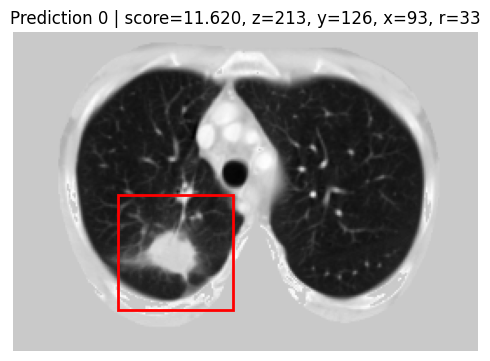

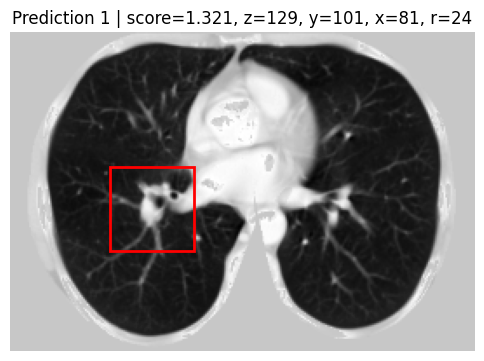

In [27]:
img = np.load("/home-local/krishar1/DeepLungScreening/mcl_adenocarcinoma_no_nodule_size/5020028474time20090101_clean.npy")
pbb = np.load("/home-local/krishar1/DeepLungScreening/bbox_root_mcl_adenocarcinoma/5020028474time20090101_pbb.npy")
pbb = pbb[pbb[:,0]>-1]
pbb = nms(pbb,0.05)

for i in range(len(pbb)):
    score = pbb[i, 0]
    box = pbb[i].astype("int")[1:]   # [z, y, x, r]

    z, y, x, r = box

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img[0, z], cmap="gray")
    ax.axis("off")

    rect = patches.Rectangle(
        (x - r, y - r),
        r * 2,
        r * 2,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)
    ax.set_title(f"Prediction {i} | score={score:.3f}, z={z}, y={y}, x={x}, r={r}")
    plt.show()

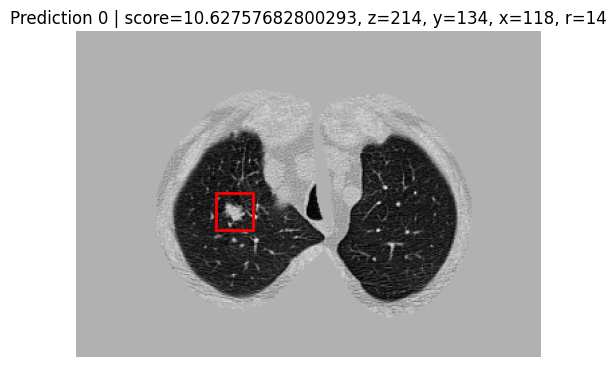

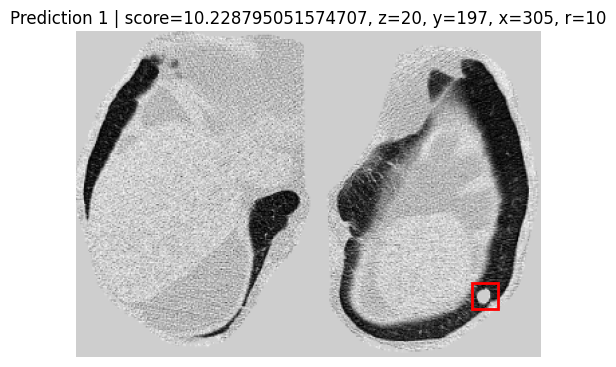

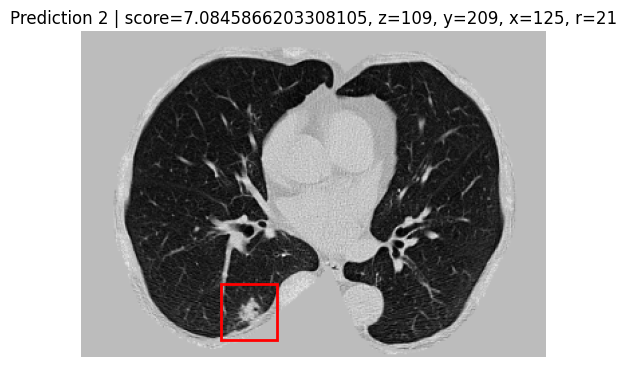

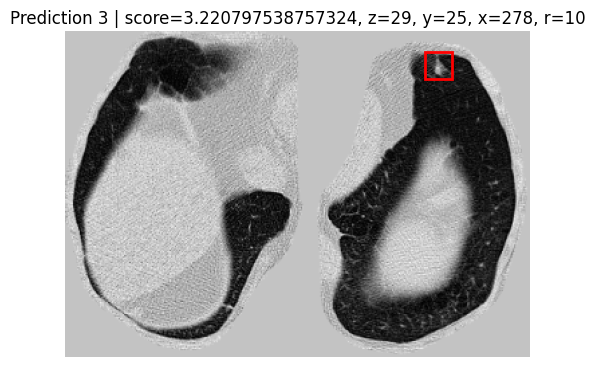

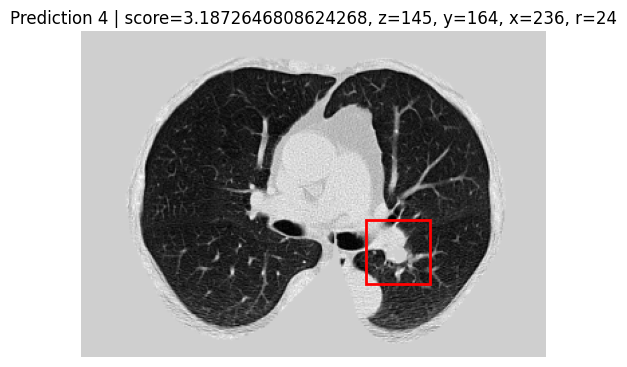

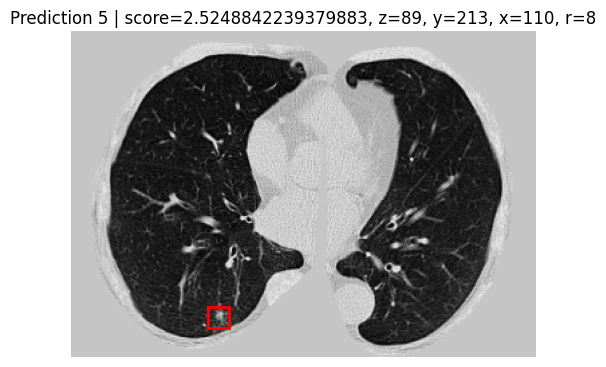

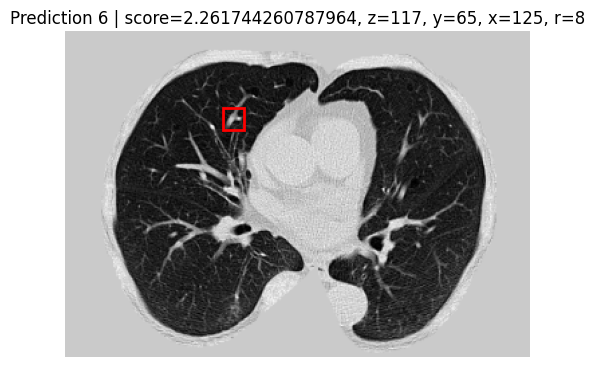

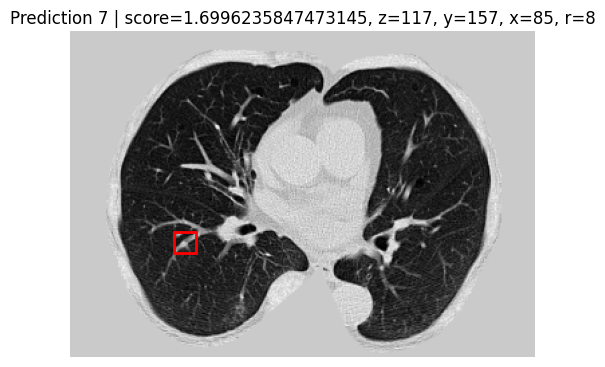

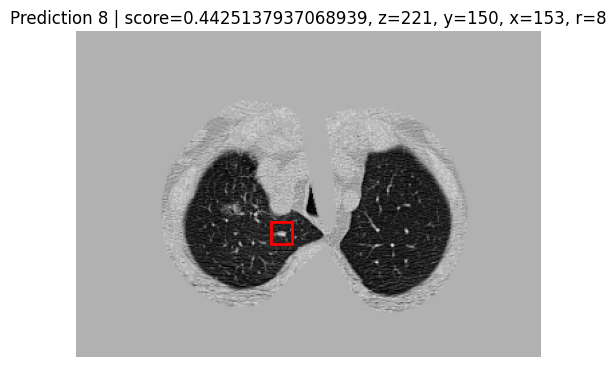

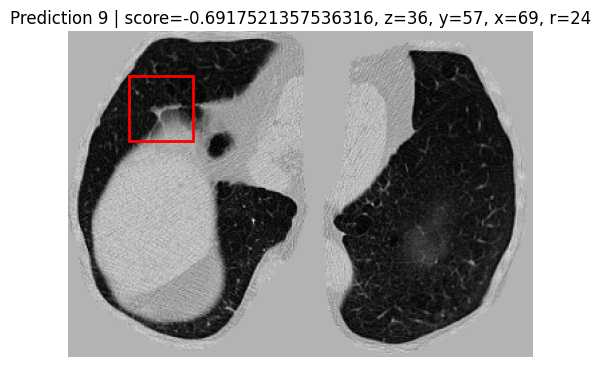

In [30]:
img = np.load("/home-local/krishar1/DeepLungScreening/mcl_adenocarcinoma_no_nodule_size/5971790817time20150101_clean.npy")
pbb = np.load("/home-local/krishar1/DeepLungScreening/bbox_root_mcl_adenocarcinoma/5971790817time20150101_pbb.npy")
pbb = pbb[pbb[:,0]>-1]
pbb = nms(pbb,0.05)

for i in range(len(pbb)):
    score = pbb[i, 0]
    box = pbb[i].astype("int")[1:]   # [z, y, x, r]

    z, y, x, r = box

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img[0, z], cmap="gray")
    ax.axis("off")

    rect = patches.Rectangle(
        (x - r, y - r),
        r * 2,
        r * 2,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)
    ax.set_title(f"Prediction {i} | score={score}, z={z}, y={y}, x={x}, r={r}")
    plt.show()

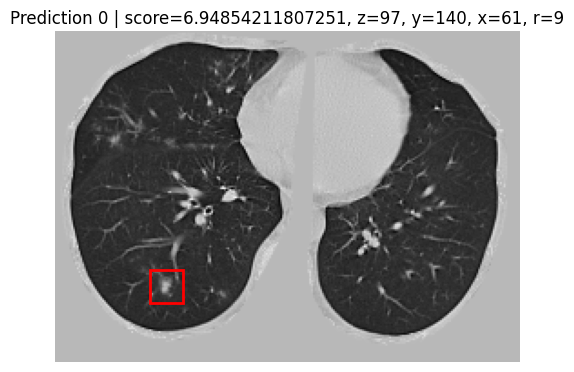

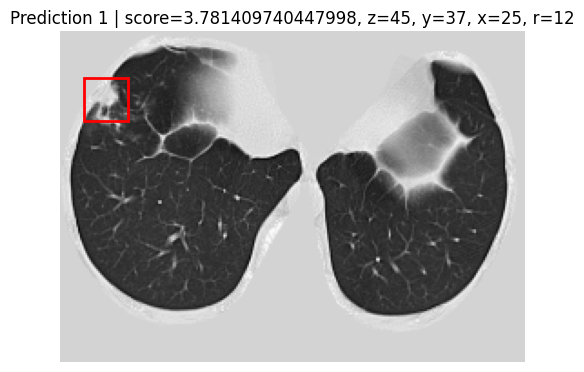

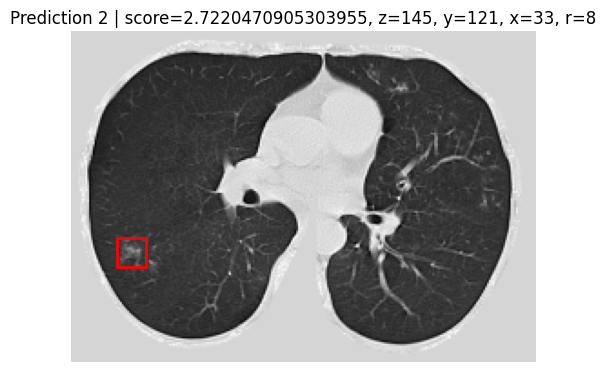

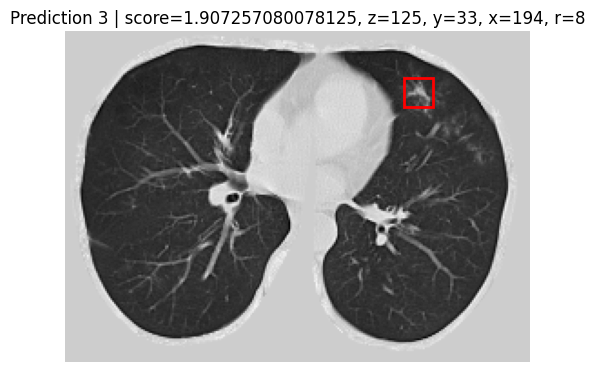

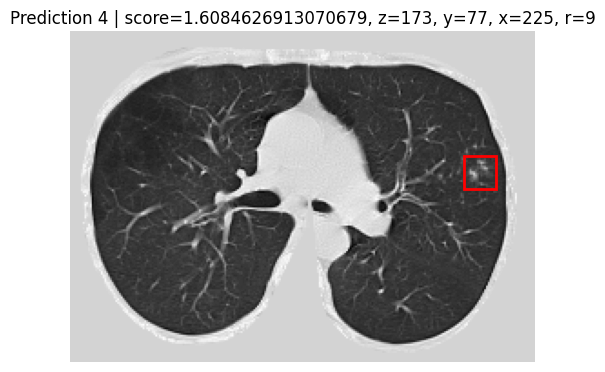

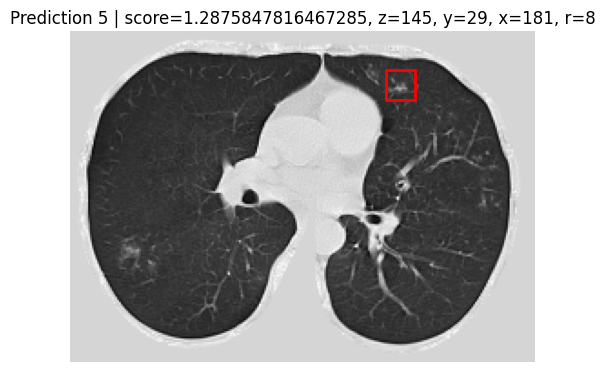

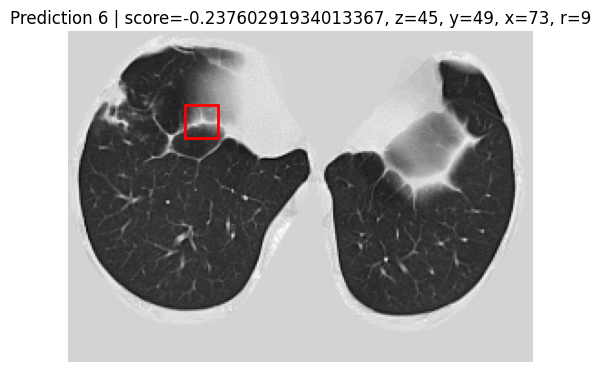

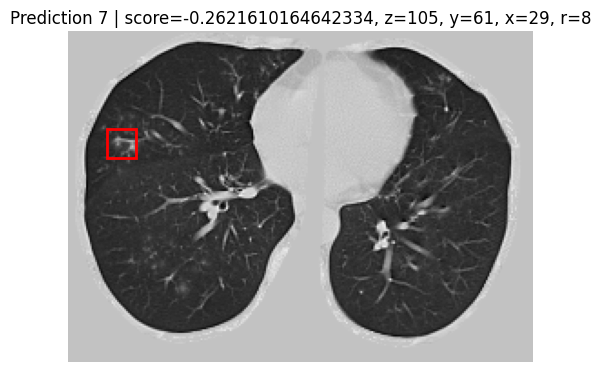

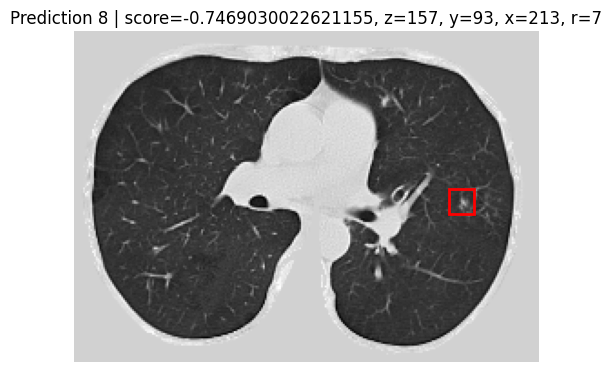

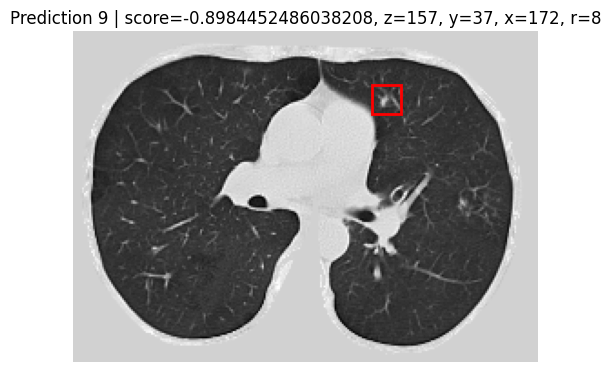

In [31]:
img = np.load("/home-local/krishar1/DeepLungScreening/mcl_adenocarcinoma_no_nodule_size/26682921997time20101015_clean.npy")
pbb = np.load("/home-local/krishar1/DeepLungScreening/bbox_root_mcl_adenocarcinoma/26682921997time20101015_pbb.npy")
pbb = pbb[pbb[:,0]>-1]
pbb = nms(pbb,0.05)

for i in range(len(pbb)):
    score = pbb[i, 0]
    box = pbb[i].astype("int")[1:]   # [z, y, x, r]

    z, y, x, r = box

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img[0, z], cmap="gray")
    ax.axis("off")

    rect = patches.Rectangle(
        (x - r, y - r),
        r * 2,
        r * 2,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)
    ax.set_title(f"Prediction {i} | score={score}, z={z}, y={y}, x={x}, r={r}")
    plt.show()

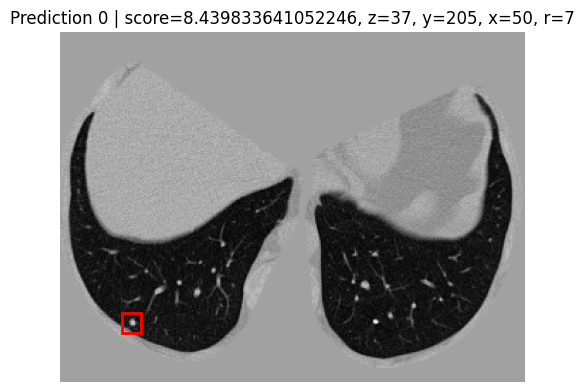

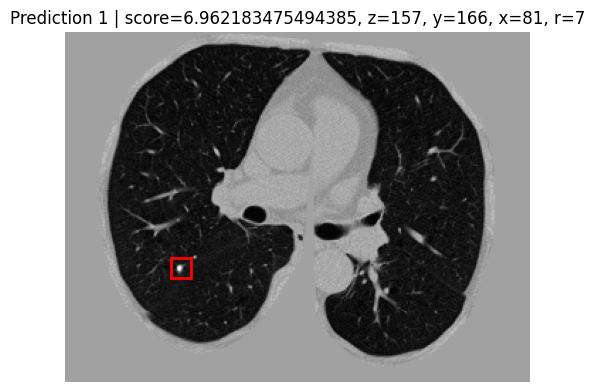

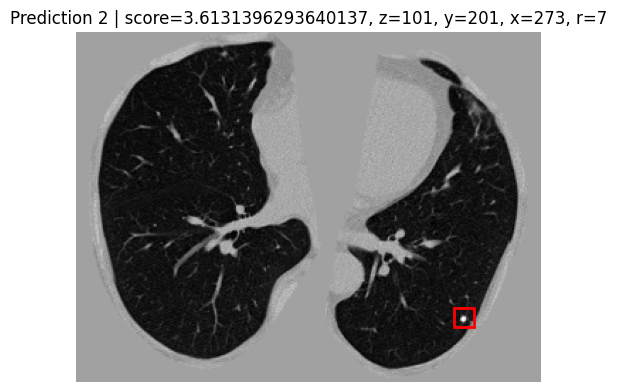

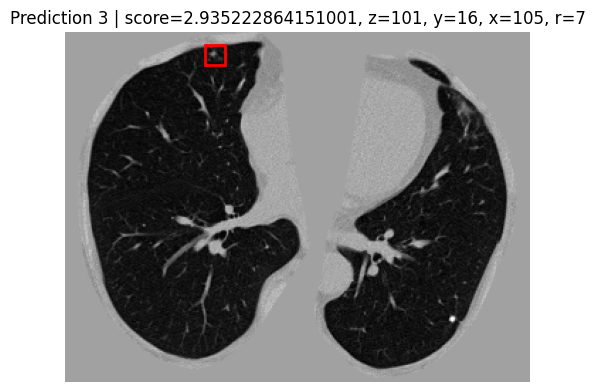

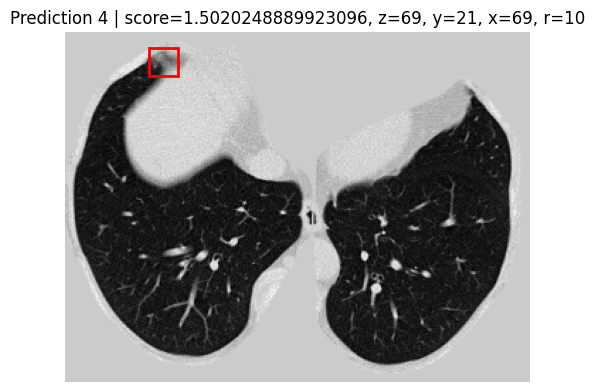

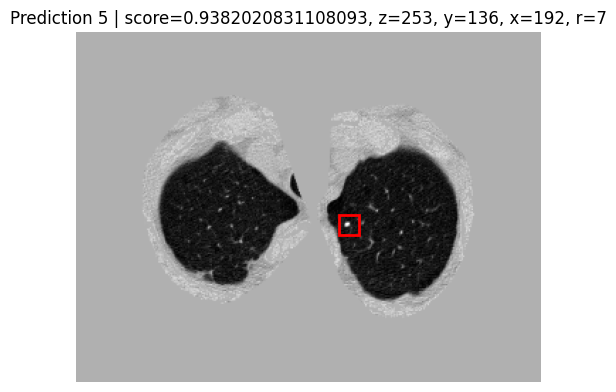

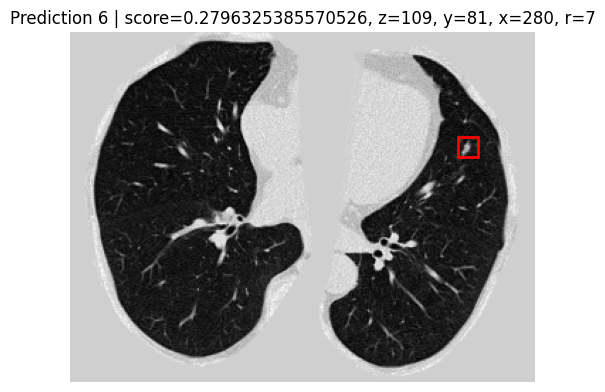

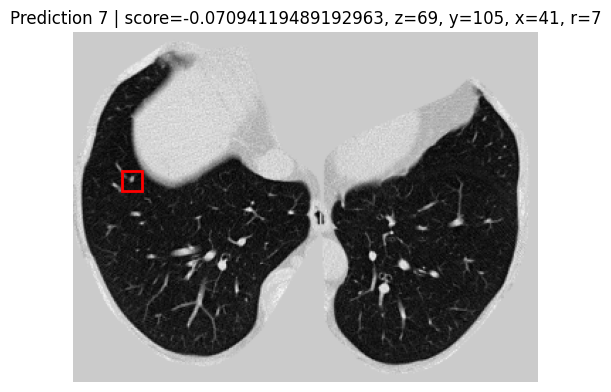

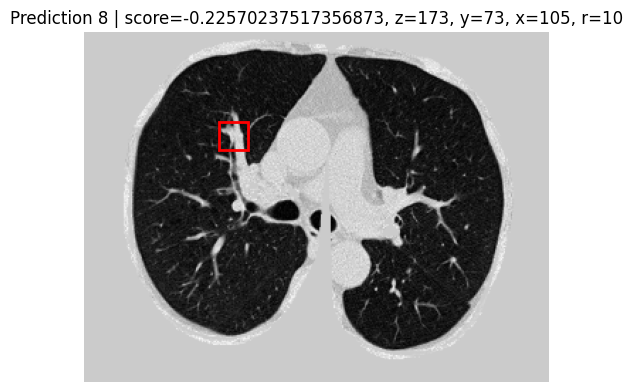

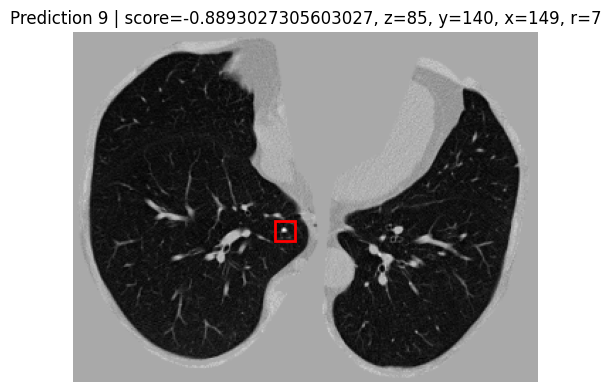

In [32]:
img = np.load("/home-local/krishar1/DeepLungScreening/mcl_adenocarcinoma_no_nodule_size/115520_clean.npy")
pbb = np.load("/home-local/krishar1/DeepLungScreening/bbox_root_mcl_adenocarcinoma/115520_pbb.npy")
pbb = pbb[pbb[:,0]>-1]
pbb = nms(pbb,0.05)

for i in range(len(pbb)):
    score = pbb[i, 0]
    box = pbb[i].astype("int")[1:]   # [z, y, x, r]

    z, y, x, r = box

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img[0, z], cmap="gray")
    ax.axis("off")

    rect = patches.Rectangle(
        (x - r, y - r),
        r * 2,
        r * 2,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)
    ax.set_title(f"Prediction {i} | score={score}, z={z}, y={y}, x={x}, r={r}")
    plt.show()

## NLST viz of adenocarcinoma

In [11]:
img = np.load("/valiant02/masi/krishar1/NLST_phenotype_journal_extension_from_SPIE/paired_NLST/DeepLungScreening/prep/NLST_SUB-112073_SES-1999_GE-BONE_clean.npy")
pbb = np.load("/valiant02/masi/krishar1/NLST_phenotype_journal_extension_from_SPIE/paired_NLST/DeepLungScreening/bbox/NLST_SUB-112073_SES-1999_GE-BONE_pbb.npy")

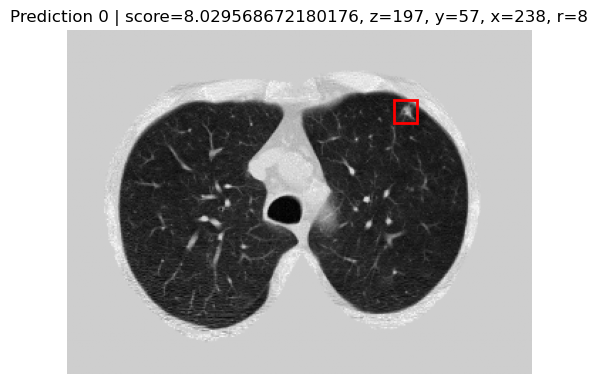

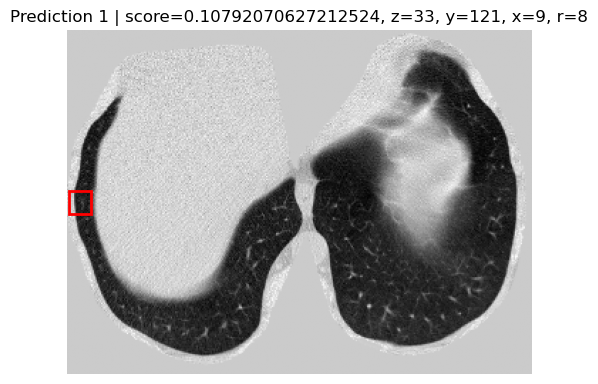

In [12]:
pbb = pbb[pbb[:,0]>-1]
pbb = nms(pbb,0.05)

for i in range(len(pbb)):
    score = pbb[i, 0]
    box = pbb[i].astype("int")[1:]   # [z, y, x, r]

    z, y, x, r = box

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img[0, z], cmap="gray")
    ax.axis("off")

    rect = patches.Rectangle(
        (x - r, y - r),
        r * 2,
        r * 2,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)
    ax.set_title(f"Prediction {i} | score={score}, z={z}, y={y}, x={x}, r={r}")
    plt.show()